# Contrastive Learning Through Time

In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/CLTT_Soccer'
FRAMES_DRIVE = f'{BASE}/frames'
CKPT_DIR    = f'{BASE}/checkpoints'
UCF_DIR     = f'{BASE}/ucf101'

for d in [BASE, FRAMES_DRIVE, CKPT_DIR, UCF_DIR]:
    os.makedirs(d, exist_ok=True)

print("Drive mounted. Directories created.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Directories created.


In [2]:
!pip install -q yt-dlp decord av

In [3]:
VIDEO_URL  = "https://www.youtube.com/watch?v=gTmR5PMIIjs"
VIDEO_PATH = f'{BASE}/soccer_asmr.mp4'

if not os.path.exists(VIDEO_PATH):
    !yt-dlp -f "bestvideo[height<=720][ext=mp4]+bestaudio[ext=m4a]/best[height<=720]" --merge-output-format mp4 -o "{VIDEO_PATH}" "{VIDEO_URL}"
else:
    print("Video already on Drive, skipping download.")

Video already on Drive, skipping download.


In [4]:
LOCAL_VIDEO = '/content/soccer_asmr.mp4'

if not os.path.exists(LOCAL_VIDEO):
    print("Copying video to local SSD...")
    !cp "{VIDEO_PATH}" "{LOCAL_VIDEO}"
    print(f"Done: {os.path.getsize(LOCAL_VIDEO)/1e9:.2f} GB")

print("Video ready.")

Video ready.


## Frame Extraction

Frames are extracted at 5 fps and scaled to 128×128. 5 fps avoids storing near-duplicate frames while still giving each 8-frame clip (~1.6s) enough motion information. The 128×128 resolution is cropped to 112×112 during augmentation.

In [5]:
import os

os.makedirs('/content/soccer_frames', exist_ok=True)

# Video is already local — ffmpeg reads it sequentially (very fast)
!ffmpeg -i /content/soccer_asmr.mp4 -vf "fps=5,scale=128:128" -q:v 3 /content/soccer_frames/frame_%06d.jpg -hide_banner -loglevel warning

n = len([f for f in os.listdir('/content/soccer_frames') if f.endswith('.jpg')])
print(f"Extracted {n} frames")

[swscaler @ 0x5a874df89700] deprecated pixel format used, make sure you did set range correctly
Extracted 55075 frames


## Model Architecture and Loss

**CLTTDataset** samples positive clip pairs: `clip_a` at frame `idx`, `clip_b` at `idx + offset` where `offset ~ Uniform(min_offset, pos_window)`. The 2s positive window bounds how far apart the clips can be; the 0.8s minimum offset prevents full overlap (at 5 fps: window = 10 frames, min_offset = 4 frames).

**CLTTModel** uses R(2+1)D-18, which factorizes 3D convolutions into separate spatial (2D) and temporal (1D) passes — more parameter-efficient than full 3D convolutions while still capturing spatiotemporal features. The two-layer MLP projection head maps the 512-dim encoder output to 128 dims for the contrastive loss; following SimCLR, this head is discarded at evaluation time.

**NTXentLoss** computes NT-Xent over a 2B × 2B similarity matrix. Temperature τ = 0.07 sharpens the softmax, pushing the model to strongly separate non-paired clips rather than settling for a diffuse embedding space.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models.video as video_models
from PIL import Image
import random, numpy as np
from tqdm import tqdm

# Kinetics-400 normalization stats
MEAN = [0.43216, 0.39467, 0.37645]
STD  = [0.22803, 0.22145, 0.21699]


from PIL import Image
import os, random, torch
from torch.utils.data import Dataset

class CLTTDataset(Dataset):
    def __init__(self, frames_dir, clip_len=8, fps=5,
                 pos_window_sec=2, min_offset_sec=0.8, transform=None):
        self.frames_dir  = frames_dir
        self.clip_len    = clip_len
        self.pos_window  = int(pos_window_sec * fps)   # max offset in frames
        self.min_offset  = max(1, int(min_offset_sec * fps))  # min offset in frames
        self.transform   = transform
        self.frames      = sorted(f for f in os.listdir(frames_dir)
                                  if f.endswith('.jpg'))
        self.N = len(self.frames)
        print(f"{self.N} frames | {self.N/fps/3600:.2f} hrs | "
              f"pos_window={pos_window_sec}s | min_offset={min_offset_sec}s")

    def _load_clip(self, start):
        imgs = []
        for i in range(self.clip_len):
            idx  = min(start + i, self.N - 1)
            img  = Image.open(f'{self.frames_dir}/{self.frames[idx]}').convert('RGB')
            imgs.append(self.transform(img) if self.transform else img)
        return torch.stack(imgs, dim=1)   # C, T, H, W

    def __len__(self):
        return max(0, self.N - self.clip_len - self.pos_window - 1)

    def __getitem__(self, idx):
        clip_a = self._load_clip(idx)
        offset = random.randint(self.min_offset, self.pos_window)
        clip_b = self._load_clip(min(idx + offset, self.N - self.clip_len - 1))
        return clip_a, clip_b



class CLTTModel(nn.Module):
    """R(2+1)D-18 encoder + MLP projection head."""
    def __init__(self, proj_dim=128):
        super().__init__()
        backbone = video_models.r2plus1d_18(weights=None)

        self.stem    = backbone.stem
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool   # → (B, 512, 1, 1, 1)

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, proj_dim),
        )

    def encode(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        return x.flatten(1)              # (B, 512)

    def forward(self, x):
        z = self.projector(self.encode(x))
        return F.normalize(z, dim=-1)   # (B, proj_dim)


class NTXentLoss(nn.Module):
    """NT-Xent (Normalized Temperature-scaled Cross Entropy)."""
    def __init__(self, temperature=0.07):
        super().__init__()
        self.T = temperature

    def forward(self, z_a, z_b):
        B   = z_a.size(0)
        z   = torch.cat([z_a, z_b], dim=0)                     # (2B, D)
        sim = torch.mm(z, z.T) / self.T                        # (2B, 2B)

        mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
        sim  = sim.masked_fill(mask, float('-inf'))

        labels = torch.cat([
            torch.arange(B, 2 * B, device=z.device),
            torch.arange(0, B,     device=z.device),
        ])
        return F.cross_entropy(sim, labels)

print("Classes defined.")

Classes defined.


## Pre-training

Augmentations (RandomCrop, RandomHorizontalFlip, ColorJitter) are applied independently to each clip in a pair. This forces the encoder to match semantically similar clips despite different appearance — preventing it from exploiting low-level pixel statistics. `drop_last=True` avoids a final batch of size 1 that would break BatchNorm. AdamW with CosineAnnealingLR decays the learning rate smoothly across all batches in both epochs.

In [7]:
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import json

def run_pretraining(frames_dir, ckpt_dir, epochs=2, batch_size=32, lr=3e-4):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    train_transform = T.Compose([
        T.RandomCrop(112),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

    dataset = CLTTDataset(frames_dir, clip_len=8, fps=5,
                          pos_window_sec=2, min_offset_sec=0.8,
                          transform=train_transform)

    loader = DataLoader(dataset, batch_size=32, shuffle=True,
                        num_workers=4, pin_memory=True, drop_last=True)

    model     = CLTTModel(proj_dim=128).to(device)
    criterion = NTXentLoss(temperature=0.07)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(loader))
    scaler = torch.amp.GradScaler('cuda')

    loss_history = {'batch': [], 'epoch': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}')

        for clip_a, clip_b in pbar:
            clip_a, clip_b = clip_a.to(device), clip_b.to(device)

            optimizer.zero_grad()
            with autocast():
                z_a = model(clip_a)
                z_b = model(clip_b)
                loss = criterion(z_a, z_b)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            batch_loss = loss.item()
            running_loss += batch_loss
            loss_history['batch'].append(batch_loss)
            pbar.set_postfix(loss=f'{batch_loss:.4f}')

        avg = running_loss / len(loader)
        loss_history['epoch'].append(avg)
        print(f'Epoch {epoch+1} — avg loss: {avg:.4f}')

        ckpt = f'{ckpt_dir}/cltt_epoch{epoch+1}.pt'
        torch.save({'epoch': epoch+1,
                    'model_state_dict': model.state_dict(),
                    'loss': avg}, ckpt)
        print(f'Saved → {ckpt}')

    with open(f'{ckpt_dir}/loss_history.json', 'w') as f:
        json.dump(loss_history, f)
    print("Loss history saved.")

    return model

print("Pretraining function ready.")

Pretraining function ready.


In [ ]:
LOCAL_FRAMES = '/content/soccer_frames'

pretrained_model = run_pretraining(
    frames_dir = LOCAL_FRAMES,
    ckpt_dir   = CKPT_DIR,
    epochs     = 2,
    batch_size = 32,
    lr         = 3e-4,
)

Device: cuda
55075 frames | 3.06 hrs | pos_window=2s | min_offset=0.8s


Epoch 1/2:   0%|          | 0/1720 [00:00<?, ?it/s]/tmp/ipykernel_796/69783381.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_796/69783381.py:50: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
Epoch 1/2: 100%|██████████| 1720/1720 [09:37<00:00,  2.98it/s, loss=0.4965]


Epoch 1 — avg loss: 0.6132
Saved → /content/drive/MyDrive/CLTT_Soccer/checkpoints/cltt_epoch1.pt


Epoch 2/2: 100%|██████████| 1720/1720 [09:41<00:00,  2.96it/s, loss=0.0591]


Epoch 2 — avg loss: 0.2293
Saved → /content/drive/MyDrive/CLTT_Soccer/checkpoints/cltt_epoch2.pt
Loss history saved.


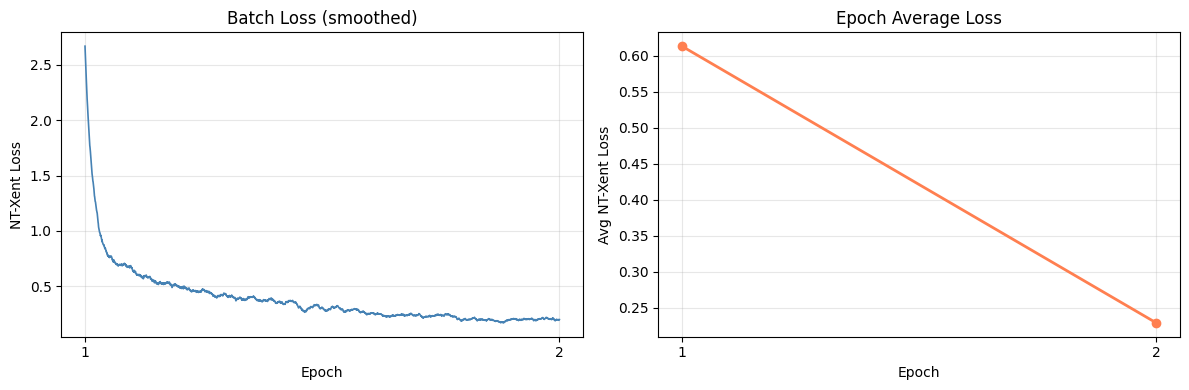

Plot saved to Drive.


In [ ]:
import json, matplotlib.pyplot as plt
import numpy as np

with open(f'{CKPT_DIR}/loss_history.json') as f:
    history = json.load(f)

batch_losses = history['batch']
epoch_losses = history['epoch']
n_epochs     = len(epoch_losses)
epoch_size   = len(batch_losses) // n_epochs

# Smooth batch losses with a rolling average for readability
window  = max(1, epoch_size // 20)
smooth  = np.convolve(batch_losses, np.ones(window) / window, mode='valid')
x_smooth = np.linspace(1, n_epochs, len(smooth))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: smoothed batch loss
axes[0].plot(x_smooth, smooth, linewidth=1.2, color='steelblue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NT-Xent Loss')
axes[0].set_title('Batch Loss (smoothed)')
axes[0].set_xticks(range(1, n_epochs + 1))
axes[0].grid(alpha=0.3)

# Right: per-epoch average
axes[1].plot(range(1, n_epochs + 1), epoch_losses,
             marker='o', linewidth=2, color='coral')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Avg NT-Xent Loss')
axes[1].set_title('Epoch Average Loss')
axes[1].set_xticks(range(1, n_epochs + 1))
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/loss_curve.png', dpi=150)
plt.show()
print("Plot saved to Drive.")

In [8]:
import shutil

ucf101_dir = f'{UCF_DIR}/UCF-101'

if os.path.exists(ucf101_dir):
    n = sum(len(os.listdir(f'{ucf101_dir}/{c}')) for c in os.listdir(ucf101_dir))
    print(f"UCF-101 ready — {n} videos across {len(os.listdir(ucf101_dir))} classes.")
else:
    split_dirs_exist = any(os.path.exists(f'{UCF_DIR}/{s}') for s in ['train', 'test', 'val'])
    if not split_dirs_exist:
        zip_path = f'{UCF_DIR}/archive.zip'
        if not os.path.exists(zip_path):
            raise FileNotFoundError(f"archive.zip not found at {zip_path} — upload it to Drive first.")
        print("Extracting UCF101 from Drive archive.zip...")
        !unzip -oq "{zip_path}" -d "{UCF_DIR}/"

    print("Merging train/test/val into UCF-101/ (one-time, may take a few minutes)...")
    os.makedirs(ucf101_dir, exist_ok=True)
    for split in ['train', 'test', 'val']:
        split_dir = f'{UCF_DIR}/{split}'
        if not os.path.exists(split_dir):
            continue
        for cls in os.listdir(split_dir):
            cls_dst = f'{ucf101_dir}/{cls}'
            os.makedirs(cls_dst, exist_ok=True)
            for video in os.listdir(f'{split_dir}/{cls}'):
                src = f'{split_dir}/{cls}/{video}'
                dst = f'{cls_dst}/{video}'
                if not os.path.exists(dst):
                    shutil.move(src, dst)

    n = sum(len(os.listdir(f'{ucf101_dir}/{c}')) for c in os.listdir(ucf101_dir))
    print(f"Done — {n} videos across {len(os.listdir(ucf101_dir))} classes.")

UCF-101 ready — 13451 videos across 101 classes.


In [9]:
splits_dir  = f'{UCF_DIR}/ucfTrainTestlist'
n_splits    = len(os.listdir(splits_dir)) if os.path.exists(splits_dir) else 0

if n_splits < 6:
    drive_zip = f'{UCF_DIR}/splits.zip'
    if os.path.exists(drive_zip):
        print("Found splits.zip on Drive — extracting...")
        !unzip -o "{drive_zip}" -d /tmp/ucf_splits_dir/
    else:
        print("Downloading UCF101 train/test splits from UCF website...")
        !wget -c "https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip" \
            -O /tmp/ucf_splits.zip
        !unzip -o /tmp/ucf_splits.zip -d /tmp/ucf_splits_dir/
    !cp -rf /tmp/ucf_splits_dir/ucfTrainTestlist "{UCF_DIR}/"
    print(f"Splits ready ({len(os.listdir(splits_dir))} files).")
else:
    print(f"Splits already present ({n_splits} files).")

Splits already present (7 files).


## Downstream Evaluation: Feature Extraction on UCF-101

The pre-trained encoder is run over all UCF-101 train and test clips with weights frozen, producing fixed 512-dim feature vectors. Keeping the encoder frozen isolates representation quality from any supervised fine-tuning signal.

In [ ]:
import glob
from torchvision.datasets import UCF101

device = torch.device('cuda')

# Load pretrained model from checkpoint if not already in memory
if 'pretrained_model' not in vars() or pretrained_model is None:
    ckpts = sorted(glob.glob(f'{CKPT_DIR}/cltt_epoch*.pt'))
    if not ckpts:
        raise FileNotFoundError(f"No checkpoints in {CKPT_DIR} — run pretraining first.")
    latest = ckpts[-1]
    print(f"Loading checkpoint: {latest}")
    pretrained_model = CLTTModel(proj_dim=128).to(device)
    state = torch.load(latest, map_location=device)
    pretrained_model.load_state_dict(state['model_state_dict'])
    pretrained_model.eval()
    print(f"Loaded epoch {state['epoch']}, loss {state['loss']:.4f}")

def make_ucf_transform():
    return T.Compose([
        T.Resize(128),
        T.CenterCrop(112),
        T.ConvertImageDtype(torch.float32),
        T.Normalize(MEAN, STD),
    ])

def ucf_collate(batch):
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[2] for item in batch])
    return videos, None, labels

def load_ucf101(ucf_dir, split='train', fold=1):
    return UCF101(
        root               = f'{ucf_dir}/UCF-101',
        annotation_path    = f'{ucf_dir}/ucfTrainTestlist',
        frames_per_clip    = 16,
        step_between_clips = 8,
        fold               = fold,
        train              = (split == 'train'),
        transform          = make_ucf_transform(),
        output_format      = 'TCHW',
    )

@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    features, labels = [], []
    for videos, _, lbls in tqdm(loader, desc='Extracting'):
        x = videos.permute(0, 2, 1, 3, 4).to(device)
        h = model.encode(x).cpu()
        features.append(h)
        labels.append(lbls)
    return torch.cat(features), torch.cat(labels)

train_ds = load_ucf101(UCF_DIR, 'train')
test_ds  = load_ucf101(UCF_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=16, num_workers=4, collate_fn=ucf_collate)
test_loader  = DataLoader(test_ds,  batch_size=16, num_workers=4, collate_fn=ucf_collate)

print("Extracting train features...")
train_feats, train_labels = extract_features(pretrained_model, train_loader, device)
print("Extracting test features...")
test_feats, test_labels   = extract_features(pretrained_model, test_loader,  device)

print(f"Train: {train_feats.shape}, Test: {test_feats.shape}")
torch.save({'feats': train_feats, 'labels': train_labels}, f'{CKPT_DIR}/train_feats.pt')
torch.save({'feats': test_feats,  'labels': test_labels},  f'{CKPT_DIR}/test_feats.pt')
print("Features saved.")

In [10]:
import glob
from torchvision.datasets import UCF101

device = torch.device('cuda')

def make_ucf_transform():
    return T.Compose([
        T.Resize(128),
        T.CenterCrop(112),
        T.ConvertImageDtype(torch.float32),
        T.Normalize(MEAN, STD),
    ])

def ucf_collate(batch):
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[2] for item in batch])
    return videos, None, labels

def load_ucf101(ucf_dir, split='train', fold=1):
    return UCF101(
        root            = f'{ucf_dir}/UCF-101',
        annotation_path = f'{ucf_dir}/ucfTrainTestlist',
        frames_per_clip    = 16,
        step_between_clips = 8,
        fold      = fold,
        train     = (split == 'train'),
        transform = make_ucf_transform(),
        output_format = 'TCHW',
    )

@torch.no_grad()
def extract_features(model, loader, device):
    model.eval()
    features, labels = [], []
    for videos, _, lbls in tqdm(loader, desc='Extracting'):
        x = videos.permute(0, 2, 1, 3, 4).to(device)
        h = model.encode(x).cpu()
        features.append(h)
        labels.append(lbls)
    return torch.cat(features), torch.cat(labels)

NUM_CLASSES = 101
print("Ready. device:", device)

Ready. device: cuda


## Linear Probe

A single `Linear(512, 101)` layer is trained on the frozen encoder features. No encoder weights are updated. Linear probe accuracy is the standard measure for self-supervised representation quality — if the features are linearly separable, the encoder has learned meaningful structure without supervision.

In [11]:
from torch.utils.data import TensorDataset

# Load from Drive if needed
train_data = torch.load(f'{CKPT_DIR}/train_feats.pt')
test_data  = torch.load(f'{CKPT_DIR}/test_feats.pt')
train_feats, train_labels = train_data['feats'], train_data['labels']
test_feats,  test_labels  = test_data['feats'],  test_data['labels']

NUM_CLASSES = 101

# Linear probe: frozen features -> trainable linear head
probe = nn.Linear(512, NUM_CLASSES).to(device)
opt   = optim.AdamW(probe.parameters(), lr=1e-3, weight_decay=1e-4)

probe_train = DataLoader(TensorDataset(train_feats, train_labels),
                          batch_size=256, shuffle=True)
probe_test  = DataLoader(TensorDataset(test_feats, test_labels),
                          batch_size=256)

for epoch in range(20):
    probe.train()
    for x, y in probe_train:
        x, y = x.to(device), y.to(device)
        loss  = F.cross_entropy(probe(x), y)
        opt.zero_grad()
        loss.backward()
        opt.step()

    # Eval every 5 epochs
    if (epoch + 1) % 5 == 0:
        probe.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in probe_test:
                x, y = x.to(device), y.to(device)
                preds   = probe(x).argmax(dim=1)
                correct += (preds == y).sum().item()
                total   += y.size(0)
        print(f"Epoch {epoch+1:2d} — Test Acc: {100*correct/total:.2f}%")

Epoch  5 — Test Acc: 21.81%
Epoch 10 — Test Acc: 21.23%
Epoch 15 — Test Acc: 22.43%
Epoch 20 — Test Acc: 23.10%


## Baseline: Random Encoder

The CLTT linear probe result (23.04%) only demonstrates that pre-training helped if it beats a randomly initialized encoder on the same task. Here we extract features from an R(2+1)D-18 with no pre-training and run the identical linear probe. The gap between the two numbers isolates what contrastive pre-training contributes over the architecture's inductive biases alone.

In [ ]:
baseline_probe = nn.Linear(512, NUM_CLASSES).to(device)
baseline_opt   = optim.AdamW(baseline_probe.parameters(), lr=1e-3, weight_decay=1e-4)

baseline_probe_train = DataLoader(TensorDataset(baseline_train_feats, baseline_train_labels),
                                  batch_size=256, shuffle=True)
baseline_probe_test  = DataLoader(TensorDataset(baseline_test_feats, baseline_test_labels),
                                  batch_size=256)

baseline_accs = {}

for epoch in range(20):
    baseline_probe.train()
    for x, y in baseline_probe_train:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(baseline_probe(x), y)
        baseline_opt.zero_grad()
        loss.backward()
        baseline_opt.step()

    if (epoch + 1) % 5 == 0:
        baseline_probe.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in baseline_probe_test:
                x, y = x.to(device), y.to(device)
                preds   = baseline_probe(x).argmax(dim=1)
                correct += (preds == y).sum().item()
                total   += y.size(0)
        acc = 100 * correct / total
        baseline_accs[epoch + 1] = acc
        print(f"Epoch {epoch+1:2d} — Random encoder: {acc:.2f}%")

# Summary comparison
cltt_final   = 23.10   # from linear probe above
random_final = baseline_accs[20]
print(f"\n--- Comparison (epoch 20) ---")
print(f"  CLTT pre-trained : {cltt_final:.2f}%")
print(f"  Random encoder   : {random_final:.2f}%")
print(f"  Gain from pre-training: +{cltt_final - random_final:.2f}%")

In [13]:
baseline_probe = nn.Linear(512, NUM_CLASSES).to(device)
baseline_opt   = optim.AdamW(baseline_probe.parameters(), lr=1e-3, weight_decay=1e-4)

baseline_probe_train = DataLoader(TensorDataset(baseline_train_feats, baseline_train_labels),
                                  batch_size=256, shuffle=True)
baseline_probe_test  = DataLoader(TensorDataset(baseline_test_feats, baseline_test_labels),
                                  batch_size=256)

baseline_accs = {}

for epoch in range(20):
    baseline_probe.train()
    for x, y in baseline_probe_train:
        x, y = x.to(device), y.to(device)
        loss = F.cross_entropy(baseline_probe(x), y)
        baseline_opt.zero_grad()
        loss.backward()
        baseline_opt.step()

    if (epoch + 1) % 5 == 0:
        baseline_probe.eval()
        correct = total = 0
        with torch.no_grad():
            for x, y in baseline_probe_test:
                x, y = x.to(device), y.to(device)
                preds   = baseline_probe(x).argmax(dim=1)
                correct += (preds == y).sum().item()
                total   += y.size(0)
        acc = 100 * correct / total
        baseline_accs[epoch + 1] = acc
        print(f"Epoch {epoch+1:2d} — Random encoder: {acc:.2f}%")

# Summary comparison
cltt_final   = 23.04   # from linear probe above
random_final = baseline_accs[20]
print(f"\n--- Comparison (epoch 20) ---")
print(f"  CLTT pre-trained : {cltt_final:.2f}%")
print(f"  Random encoder   : {random_final:.2f}%")
print(f"  Gain from pre-training: +{cltt_final - random_final:.2f}%")

Epoch  5 — Random encoder: 11.54%
Epoch 10 — Random encoder: 11.79%
Epoch 15 — Random encoder: 13.26%
Epoch 20 — Random encoder: 14.47%

--- Comparison (epoch 20) ---
  CLTT pre-trained : 23.04%
  Random encoder   : 14.47%
  Gain from pre-training: +8.57%
